# Examples of running HypoInvPy with utility functions
The original event catalog and phase picks are the output of the QuakeFlow and GAMMA codes.

In [1]:
import os, sys,glob
import pandas as pd
import numpy as np
from hypoxpy import HypoInvCore as hypoinvcore
from hypoxpy import utils
import matplotlib.pyplot as plt

/usr/local/anaconda3/envs/hypox/lib/python3.11/site-packages/obspy/core/util/base.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Convert station information from json database to CSV
The example here uses the *.json file saved by EQTransforer downloading step. The CSV file is for general purpose. To reformat it for HypoInverse code, please see the next example.

In [2]:
infile='input/GAMMA_station_list.json'
station_csv='input/GAMMA_station_list.csv'
stainfo=utils.stainfo_json2csv(infile,informat='gamma',outfile=station_csv)
print(stainfo)

   network station channel   latitude   longitude  elevation
0       AV    DEER     BHE  54.971270 -162.324370      392.3
1       AV    DEER     BHN  54.971270 -162.324370      392.3
2       AV    DEER     BHZ  54.971270 -162.324370      392.3
3       AV     DOL     BHE  55.149621 -161.864720      453.0
4       AV     DOL     BHN  55.149621 -161.864720      453.0
5       AV     DOL     BHZ  55.149621 -161.864720      453.0
6       AV     DT1     BHE  55.106270 -162.283130      198.0
7       AV     DT1     BHN  55.106270 -162.283130      198.0
8       AV     DT1     BHZ  55.106270 -162.283130      198.0
9       AV     DTN     BHE  55.144800 -162.259000      396.0
10      AV     DTN     BHN  55.144800 -162.259000      396.0
11      AV     DTN     BHZ  55.144800 -162.259000      396.0
12      AV     HAG     SHE  55.316860 -161.904390      515.4
13      AV     HAG     SHN  55.316860 -161.904390      515.4
14      AV     HAG     SHZ  55.316860 -161.904390      515.4
15      AV    PN7A     B

## Reformat station information for HypoInverse code.
The `HypoInvPy.core.reformat_stainfo()` function takes input in `json` or `csv` format. You can specify the format as `json-gamma` for json files from running the gamma workflow. See the source code or use `help()` to get detailed usage information of this function. 

* `force_channel_type` option is to force all channels to the specified type. This is because in some earthquake detection and association steps, the original channel types might be lost, making it impossible to link the phase data with station information.
* `rename_component_dict` option is to rename component names. This is needec when some components originally having 1 or 2 in the names. These original names sometimes are not kept through the earthquake detection and association steps.
* `ignore_component` option will ignore the component code and only saves the channel type, e.g., BH instead of BHZ.

## Convert the phase picks and catalog from GAMMA to Hypoinverse format
The outputs from running GAMMA contain picks and preliminary catalog, while the solutions of locations are poor. This block shows examples of converting or merging the picks and earthquake catalog to phase data format needed by Hypoinverse. We are using Y2000-compatible format here (https://ncedc.org/ftp/pub/doc/ncsn/shadow2000.pdf).

If `qc` is True, only events with both P and S picks will be saved. 
`default_component` here to address the issue that GAMMA picks only have two letters for the channels (only channel type). Use one letter code here to replace the empty component code. If the component code also exists, the `default_component` value will be ignored.


## Setup parameters for HypoInverse code
Major parameters to run the code are carried through with a container class named `HypoInvPy.core.HypoInvConfig()`. This class is simplified from the `config()` class in `Hypo-Interface-Py`. In `HypoInvPy`, I also reduced the number of metadata/parameters, to focus only on required key parameters.

Examples here use the phase information directly from the `EQTransformer` association step. The station information file has been reformated as shown in the previous cell. 

In [3]:
# modified from https://github.com/YijianZhou/Hypo-Interface-Py
binpath='/Users/xtyang/bin' #path to hypoDD binaries.
indir='input'
outdir='output'
if not os.path.exists(outdir):
    os.makedirs(outdir)
namebase='GAMMA'
station_file=os.path.join(indir,'GAMMA_station_list.json')
station_file_reformat=os.path.join(indir,'station.dat')
event_file=os.path.join(indir,'GAMMA_catalog.csv')
phase_file=os.path.join(indir,'GAMMA_picks.csv') #input original phase file.
evid_label='event_id' #column name for event ID in the input event and pick files.
mapping_evid=True #whether to remap event IDs to integers starting from 1 for HypoDD compatibility.
        #If False, original event IDs are used (may cause issues if IDs are not integers or not starting from 1).
        #THIS SHOULD BE TRUE, UNLESS YOU ARE SURE YOUR EVENT IDS ARE INTEGERS STARTING FROM 1.
evid_label_mapped = 'event_id_mapped'
save_cleaned_data=True #whether to save cleaned event and pick data after removing invalid entries.
        #THIS SHOULD BE TRUE IF mapping_evid IS TRUE. IT IS SET AUTOMATICALLY IN THE FUNCTION IF mapping_evid IS TRUE.
cleaned_eventfile = os.path.splitext(event_file)[0] + "_cleaned.csv"
cleaned_pickfile = os.path.splitext(phase_file)[0] + "_cleaned.csv"

phase_file_reformat=f'{indir}/{namebase}_phase_ready.pha' #output reformatted phase file for hypoDD.

# combine network and station for HypoDD format.
combine_net_sta=True

pmodel=os.path.join(indir,'velo_p_eg.cre')
smodel=os.path.join(indir,'velo_s_eg.cre')
lat_code='N'
lon_code='W'
depth_try_list=np.arange(0,20,1)
min_nsta=4 #minimum number of stations to relocate the earthquake. 4 is recommeneded as the minimum to get a reliable location.
remove_summary_files=False #remove intermediate summary files from each relocation run?


In [4]:
utils.reformat_stainfo_hypoinverse(station_file,station_file_reformat,informat='json-gamma',ignore_component=False)

In [5]:
utils.convert_gamma2hypoinverse(event_file,phase_file,outfile=phase_file_reformat,qc=False,default_component='Z',verbose=False,
                                evid_label=evid_label,mapping_evid=mapping_evid,save_cleaned_data=save_cleaned_data,
                                cleaned_eventfile=cleaned_eventfile,cleaned_pickfile=cleaned_pickfile)

Cleaned event data saved to input/GAMMA_catalog_cleaned.csv
Cleaned pick data saved to input/GAMMA_picks_cleaned.csv


Converting GAMMA to HypoDD phase file: 100%|██████████| 9257/9257 [00:02<00:00, 3460.95it/s]


In [6]:

hypoinvconfig = hypoinvcore.HypoInvConfig(indir=indir,outdir=outdir,phase_file=phase_file_reformat,station_file=station_file_reformat,
                       pmodel=pmodel,smodel=smodel,min_nsta=min_nsta,namebase=namebase,
                      lat_code=lat_code,lon_code=lon_code,ztrlist=depth_try_list)
#file names for the final summary catalogs.
out_bad = '%s/%s_bad.csv'%(outdir,hypoinvconfig.namebase)
out_good = '%s/%s_good.csv'%(outdir,hypoinvconfig.namebase)

## Run hypoinverse through the interface
This is the key step to run hypoinverse. I kept the way Hypo-Interface-Py uses running the code on a series of initial depths. This list is specified as `ztrlist` in the configuration step above.

In [7]:
# 1. produce parameter files for each testing initial depth.
hypparfilelist=hypoinvcore.generate_parfile(hypoinvconfig,indir,outdir=outdir,magline="MAG 1 T 1 1")

# 2. Run hypoinverse with all parameter files.
hypoinvconfig.run(hypparfilelist, cleanup=False, merge_summary=False)

Running hyp1.40 by depth grids: 100%|██████████| 20/20 [00:27<00:00,  1.40s/it]


## Extract inversion results based on quality
In `hypoinvconfig.merge_summary`, you can pass the original event catalog to retrieve the magnitude information. Otherwise, the function will extract the magnitude from the HypoInverse results.

In [7]:
print('converting output sum files')
summary_filelist=glob.glob('%s/%s-*.sum'%(outdir,hypoinvconfig.namebase))

hypoinvconfig.merge_summary(filelist=summary_filelist,mag_dict=cleaned_eventfile,evid_label=evid_label_mapped,
                            cleanup=remove_summary_files)

converting output sum files
Earthquakes are saved in:
  output/GAMMA_good.csv (good)
  output/GAMMA_bad.csv (bad)


## Read and plot the earthquakes

In [8]:
quakes=pd.read_csv(out_good)
print(quakes)

              time   latitude   longitude  depth_km  magnitude  event_id
0     2.021010e+13  55.373500 -161.827333     30.59      2.435        10
1     2.021010e+13  54.963333 -162.305833     10.63      1.771       100
2     2.021020e+13  55.071500 -161.603667     20.27      0.658      1001
3     2.021020e+13  55.318333 -161.754333      6.37      0.207      1002
4     2.021020e+13  55.304167 -161.328667     22.39      1.265      1003
...            ...        ...         ...       ...        ...       ...
2836  2.021020e+13  55.058833 -161.747333     17.84      1.518       984
2837  2.021020e+13  54.566833 -162.348000     58.63      1.624       985
2838  2.021010e+13  55.491667 -161.818333     36.40      2.308        99
2839  2.021020e+13  55.071833 -161.173667     32.53      1.772       993
2840  2.021020e+13  54.564333 -161.273500     13.64      1.732       998

[2841 rows x 6 columns]


## Plot earthquakes scaled by magnitude and colored by depth

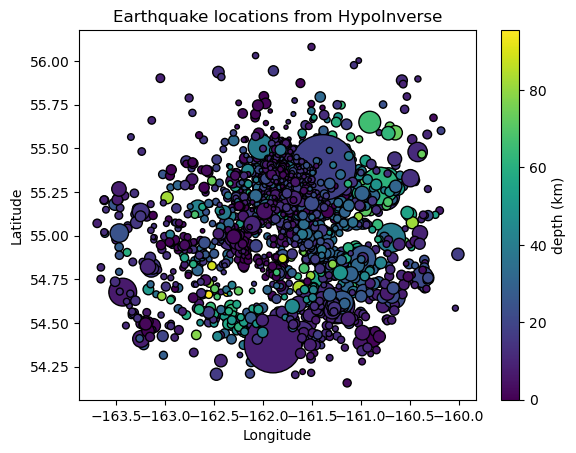

In [10]:
plt.scatter(quakes.longitude,quakes.latitude,5*np.power(3,quakes.magnitude),quakes.depth_km,edgecolors='k')
plt.colorbar(label='depth (km)')
plt.title('Earthquake locations from HypoInverse')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()